In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from evaluation_function import evaluate_strategy_full, plot_strategy_vs_buy_hold

### Load Data + Cleaning

In [2]:
# Load the data
btc = pd.read_csv("../datasets/BTC_full_data.csv")
eth = pd.read_csv("../datasets/ETH_full_data.csv")

# Clean data (remove first row due to missing Log_Return value and convert cols to numeric)
def clean_data(data):
    df = data
    # remove first row
    df = df.iloc[1:].reset_index(drop=True)

    df["Date"] = pd.to_datetime(df["Date"])
    # convert numeric columns
    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.set_index("Date")

    return df

btc = clean_data(btc)
eth = clean_data(eth)

print(btc.head())
print(eth.head())

                    Open          High           Low         Close  \
Date                                                                 
2018-01-02  13625.000000  15444.599609  13163.599609  14982.099609   
2018-01-03  14978.200195  15572.799805  14844.500000  15201.000000   
2018-01-04  15270.700195  15739.700195  14522.200195  15599.200195   
2018-01-05  15477.200195  17705.199219  15202.799805  17429.500000   
2018-01-06  17462.099609  17712.400391  16764.599609  17527.000000   

               Adj Close       Volume  Log_Return  
Date                                               
2018-01-02  14982.099609  16846600192    0.092589  
2018-01-03  15201.000000  16871900160    0.014505  
2018-01-04  15599.200195  21783199744    0.025858  
2018-01-05  17429.500000  23840899072    0.110945  
2018-01-06  17527.000000  18314600448    0.005578  
                  Open         High         Low        Close    Adj Close  \
Date                                                                

### Create breakout signals

In [3]:
# Create 20-day breakout signals
# Long when price > 20-day high
# Short when price < 20-day low

def breakout_signal(df):

    data = df.copy()

    # 20 day breakout levels
    data['high20'] = data['Close'].shift(1).rolling(20).max()
    data['low20'] = data['Close'].shift(1).rolling(20).min()

    # signal
    data['signal'] = 0
    data.loc[data['Close'] > data['high20'], 'signal'] = 1
    data.loc[data['Close'] < data['low20'], 'signal'] = -1

    # hold previous position
    data['position'] = data['signal'].replace(0, np.nan).ffill().fillna(0)

    return data

In [4]:
btc = breakout_signal(btc)
eth = breakout_signal(eth)

#print(btc)

In [5]:
# Find Strategy Returns
btc['strategy_return'] = btc['position'].shift(1) * btc['Log_Return']
eth['strategy_return'] = eth['position'].shift(1) * eth['Log_Return']

### Evaluation
We will evaluate the strategy using 6 metrics:
1. Cumulative PnL
2. Average Daily PnL
3. Volatility
4. Annualised Return
5. Sharpe Ratio
6. Max Drawdown

In [6]:
def evaluate_strategy(strategy_returns):
    r = strategy_returns.dropna()

    # cumulative pnl
    cumulative_pnl = np.exp(r.cumsum()).iloc[-1] - 1
    # average daily pnl
    avg_daily_pnl = r.mean()
    # volatility
    volatility = r.std()
    # annualised return
    annual_return = r.mean() * 365
    # annualised volatility
    annual_vol = volatility * np.sqrt(365)
    # sharpe ratio
    rf = 0.03
    sharpe = (annual_return - rf) / annual_vol
    # max drawdown
    cumulative = np.exp(r.cumsum())
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_dd = drawdown.min()

    return {
        "Cumulative PnL": cumulative_pnl,
        "Average Daily PnL": avg_daily_pnl,
        "Volatility": volatility,
        "Annualised Return": annual_return,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd
    }


In [7]:
# Run evaluation
btc_results = evaluate_strategy(btc['strategy_return'])
eth_results = evaluate_strategy(eth['strategy_return'])

print("BTC Results")
print(btc_results)

print("\nETH Results")
print(eth_results)

BTC Results
{'Cumulative PnL': np.float64(45.95817178190562), 'Average Daily PnL': np.float64(0.0013186903882739158), 'Volatility': np.float64(0.03367532591850597), 'Annualised Return': np.float64(0.48132199171997925), 'Sharpe Ratio': np.float64(0.7015009381913062), 'Max Drawdown': np.float64(-0.5104578324177506)}

ETH Results
{'Cumulative PnL': np.float64(118.41971491748393), 'Average Daily PnL': np.float64(0.0016384529989346046), 'Volatility': np.float64(0.04417113015424797), 'Annualised Return': np.float64(0.5980353446111307), 'Sharpe Ratio': np.float64(0.6731167783300379), 'Max Drawdown': np.float64(-0.8547008874835758)}


### Results Interpretation
BTC:
1. Cumulative PnL: 45.96 -> The portfolio grew 45.96 times its initial value
2. Average Daily PnL: 0.132% avarage return per day
3. Volatility: 3.37%
4. Annualised Return: 0.48 -> 48% per year
5. Sharpe Ratio: 0,70
6. Max Drawdown: -0.51

ETH:
1. Cumulative PnL: 118.42 -> The portfolio grew 118.42 times its initial value
2. Average Daily PnL: 0.164% avarage return per day
3. Volatility: 4.42%
4. Annualised Return: 0.60 -> 60% per year
5. Sharpe Ratio: 0,67
6. Max Drawdown: -0.85



## Trying other window sizes

In [8]:
def breakout_signal_size(df, size):

    data = df.copy()

    # breakout levels
    data['high20'] = data['Close'].shift(1).rolling(size).max()
    data['low20'] = data['Close'].shift(1).rolling(size).min()

    # signal
    data['signal'] = 0
    data.loc[data['Close'] > data['high20'], 'signal'] = 1
    data.loc[data['Close'] < data['low20'], 'signal'] = -1

    # hold previous position
    data['position'] = data['signal'].replace(0, np.nan).ffill().fillna(0)

    return data

In [9]:
# Window size:30
btc_30 = breakout_signal_size(btc, 30)
eth_30 = breakout_signal_size(eth, 30)
# Find Strategy Returns
btc_30['strategy_return'] = btc_30['position'].shift(1) * btc_30['Log_Return']
eth_30['strategy_return'] = eth_30['position'].shift(1) * eth_30['Log_Return']

##########################
#Window size:60
btc_60 = breakout_signal_size(btc, 60)
eth_60 = breakout_signal_size(eth, 60)
# Find Strategy Returns
btc_60['strategy_return'] = btc_60['position'].shift(1) * btc_60['Log_Return']
eth_60['strategy_return'] = eth_60['position'].shift(1) * eth_60['Log_Return']

###########################
#Window size:90
btc_90 = breakout_signal_size(btc, 90)
eth_90 = breakout_signal_size(eth, 90)
# Find Strategy Returns
btc_90['strategy_return'] = btc_90['position'].shift(1) * btc_90['Log_Return']
eth_90['strategy_return'] = eth_90['position'].shift(1) * eth_90['Log_Return']

### Evaluation: Window Size 30

In [10]:
# Window size 30 Evaluation
btc_results_30 = evaluate_strategy(btc_30['strategy_return'])
eth_results_30 = evaluate_strategy(eth_30['strategy_return'])

print("BTC_30 Results")
print(btc_results_30)

print("\nETH_30 Results")
print(eth_results_30)

BTC_30 Results
{'Cumulative PnL': np.float64(24.219938854650582), 'Average Daily PnL': np.float64(0.001105733095599613), 'Volatility': np.float64(0.03353174382899179), 'Annualised Return': np.float64(0.40359257989385877), 'Sharpe Ratio': np.float64(0.5831706654324663), 'Max Drawdown': np.float64(-0.7699111157416677)}

ETH_30 Results
{'Cumulative PnL': np.float64(815.4311834283599), 'Average Daily PnL': np.float64(0.002296999872034367), 'Volatility': np.float64(0.044141773534273225), 'Annualised Return': np.float64(0.8384049532925439), 'Sharpe Ratio': np.float64(0.9585896936497177), 'Max Drawdown': np.float64(-0.6642550771467488)}


### Evaluation: Window Size 60

In [11]:
# Window size 60 Evaluation
btc_results_60 = evaluate_strategy(btc_60['strategy_return'])
eth_results_60 = evaluate_strategy(eth_60['strategy_return'])

print("BTC_60 Results")
print(btc_results_60)

print("\nETH_60 Results")
print(eth_results_60)

BTC_60 Results
{'Cumulative PnL': np.float64(30.76177583423568), 'Average Daily PnL': np.float64(0.0011847425656019133), 'Volatility': np.float64(0.032531969511920875), 'Annualised Return': np.float64(0.4324310364446984), 'Sharpe Ratio': np.float64(0.6474924046352082), 'Max Drawdown': np.float64(-0.541062221039649)}

ETH_60 Results
{'Cumulative PnL': np.float64(56.6617040186924), 'Average Daily PnL': np.float64(0.0013890350272857792), 'Volatility': np.float64(0.04363641890628393), 'Annualised Return': np.float64(0.5069977849593094), 'Sharpe Ratio': np.float64(0.572164393706218), 'Max Drawdown': np.float64(-0.7979934091949977)}


### Evaluation: Window Size 90

In [12]:
# Window size 90 Evaluation
btc_results_90 = evaluate_strategy(btc_90['strategy_return'])
eth_results_90 = evaluate_strategy(eth_90['strategy_return'])

print("BTC_90 Results")
print(btc_results_90)

print("\nETH_90 Results")
print(eth_results_90)

BTC_90 Results
{'Cumulative PnL': np.float64(17.934521647496), 'Average Daily PnL': np.float64(0.0010075323049542472), 'Volatility': np.float64(0.03247767576238198), 'Annualised Return': np.float64(0.3677492913083002), 'Sharpe Ratio': np.float64(0.5443310050943418), 'Max Drawdown': np.float64(-0.8634830726898994)}

ETH_90 Results
{'Cumulative PnL': np.float64(7.692039057179688), 'Average Daily PnL': np.float64(0.0007408042329040755), 'Volatility': np.float64(0.04333628818754288), 'Annualised Return': np.float64(0.2703935450099876), 'Sharpe Ratio': np.float64(0.2903518911217327), 'Max Drawdown': np.float64(-0.8856350218131627)}


### Plots

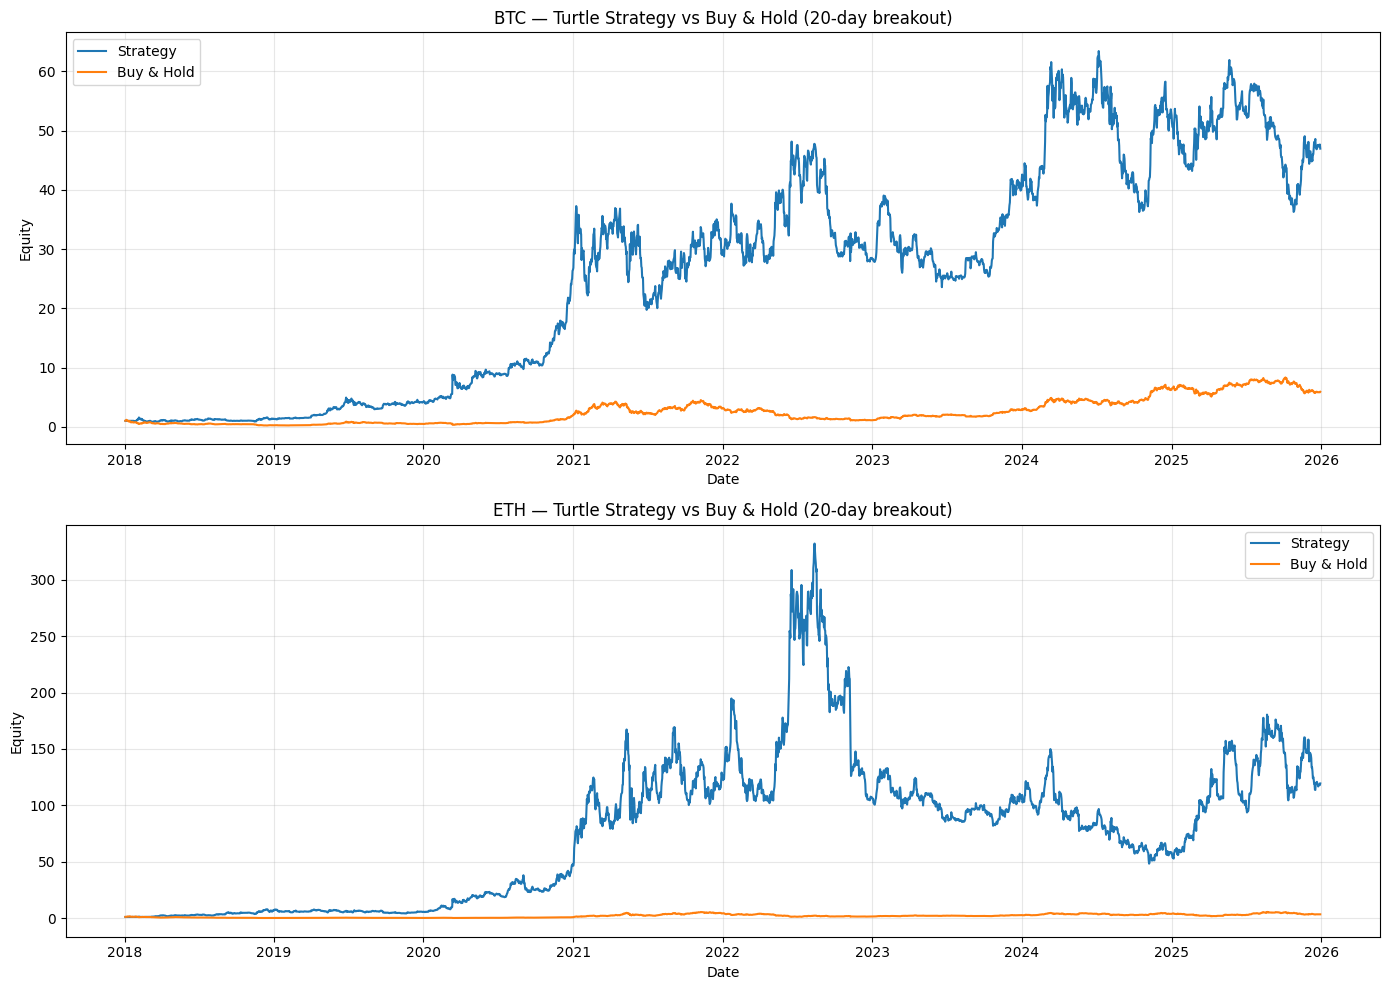

In [19]:
### This is using results from the 20-day window
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, (asset, df, label) in zip(axes, [
    ("BTC", btc, "BTC"),
    ("ETH", eth, "ETH")
]):
    r = df['strategy_return'].dropna()

    # strategy equity curve
    strategy_equity = np.exp(r.cumsum())

    # buy & hold equity curve 
    bh_returns = df['Log_Return'].loc[r.index]
    bh_equity = np.exp(bh_returns.cumsum())

    ax.plot(strategy_equity.index, strategy_equity, label="Strategy", linewidth=1.5)
    ax.plot(bh_equity.index, bh_equity, label="Buy & Hold", linewidth=1.5, linestyle="-")
    ax.set_title(f"{label} — Turtle Strategy vs Buy & Hold (20-day breakout)")
    ax.set_ylabel("Equity")
    ax.set_xlabel("Date")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

